<a href="https://colab.research.google.com/github/Abhijeet141022/Quantum-Techonology-Course/blob/main/Grover_algorithm_book.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install qiskit

In [2]:
pip install qiskit-ibm-runtime

In [3]:
pip install -U matplotlib pylatexenc

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 43.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 10.3 MB/s eta 0:00:00
  Attempting uninstall: matplotlib
    Found existing installation: matplotlib 3.10.0
    Uninstalling matplotlib-3.10.0:
      Successfully uninstalled matplotlib-3.10.0


In [3]:
import math
from qiskit import QuantumCircuit
from qiskit.circuit.library import grover_operator, MCMTGate, ZGate
from qiskit.visualization import plot_distribution
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import SamplerV2 as Sampler

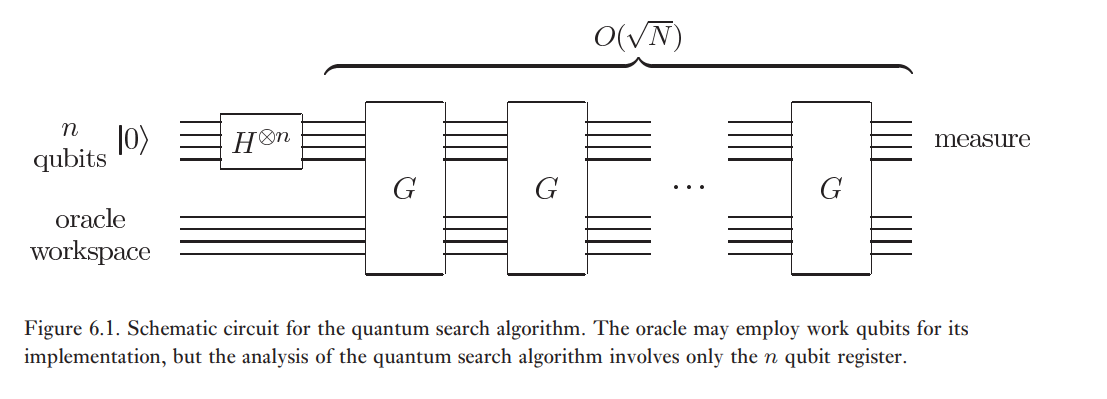

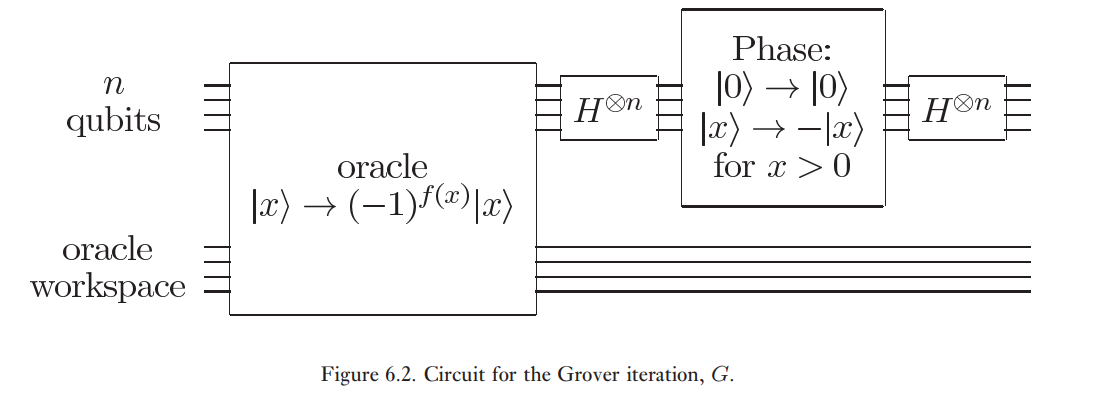

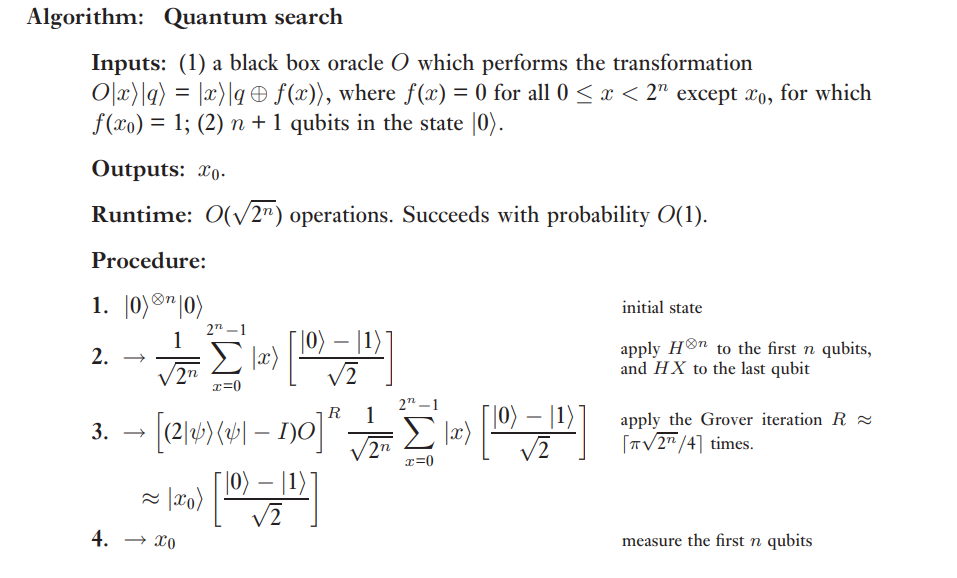

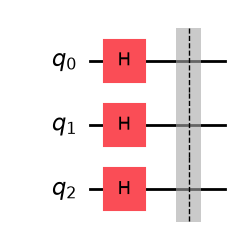

In [5]:
N = '110' # set the state to search
num_qubits = len(N)
qc = QuantumCircuit(num_qubits) # create the quantum circuit
qc.h(range(num_qubits)) # set all qubits in superposition
qc.barrier()
qc.draw(output='mpl')

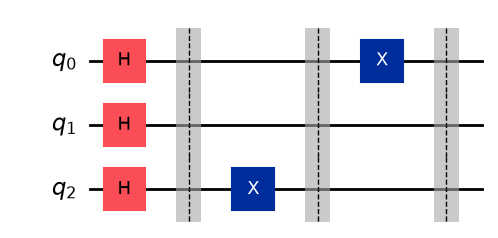

In [8]:
N = N[::-1] # reverse the state so it is in the proper qubit ordering
for idx in range(num_qubits): # Encode N into our circuit
    if N[idx] == '0':
        qc.x(idx)
qc.barrier()
qc.draw(output='mpl')

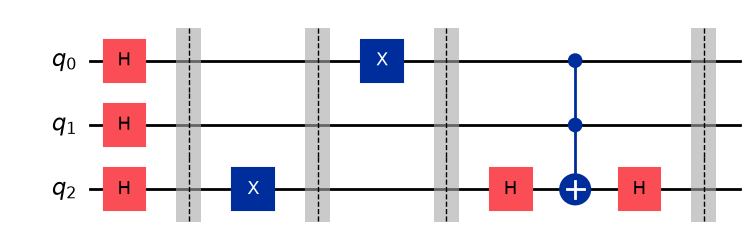

In [9]:
qc.h(2) # Create the Grover oracle for 3-qubit quantum circuit
qc.ccx(0, 1, 2)
qc.h(2)
qc.barrier()
qc.draw(output='mpl')

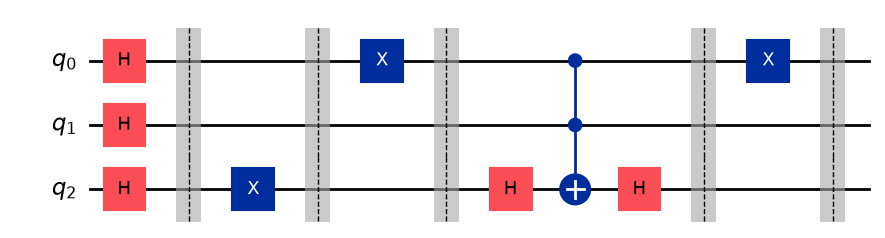

In [10]:
for idx in range(num_qubits): # Reset the value after the oracle
    if N[idx] == '0':
        qc.x(idx)
qc.barrier()
qc.draw(output='mpl')

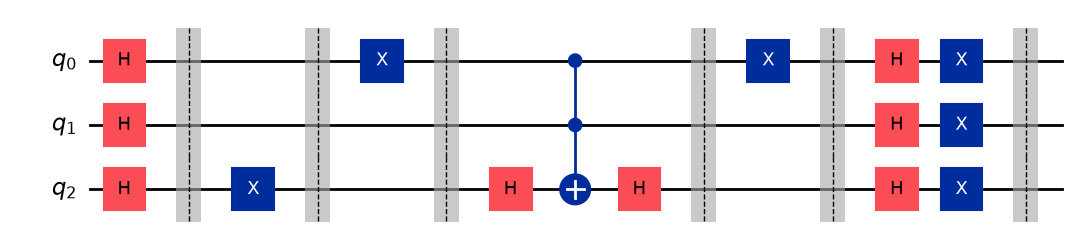

In [11]:
qc.h(range(num_qubits)) # Set all qubits in superposition
qc.x(range(num_qubits))
qc.barrier()
qc.draw(output='mpl')

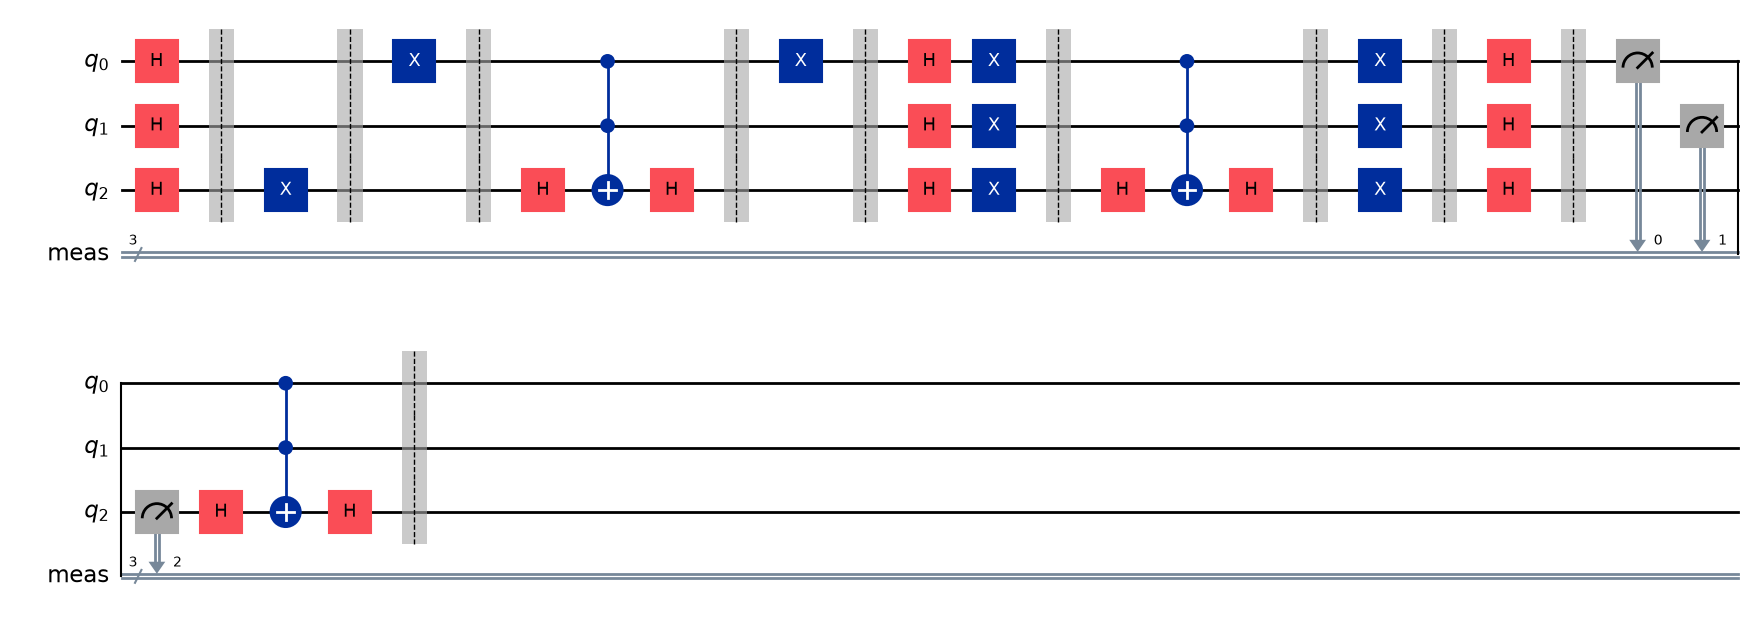

In [19]:
qc.h(2) # apply another same oracle
qc.ccx(0, 1, 2)
qc.h(2)
qc.barrier()
qc.draw(output='mpl')

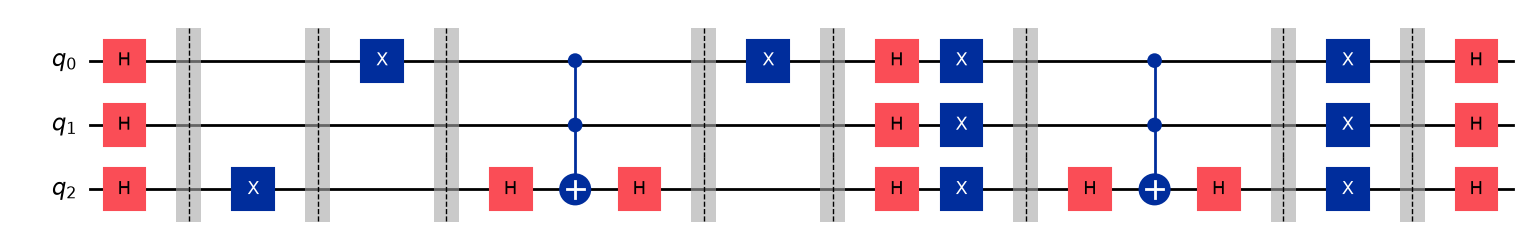

In [13]:
qc.x(range(num_qubits)) # reapply the X rotations on all qubits
qc.barrier()
qc.h(range(num_qubits)) # reapply hadamard gates to all qubits
qc.draw(output='mpl')

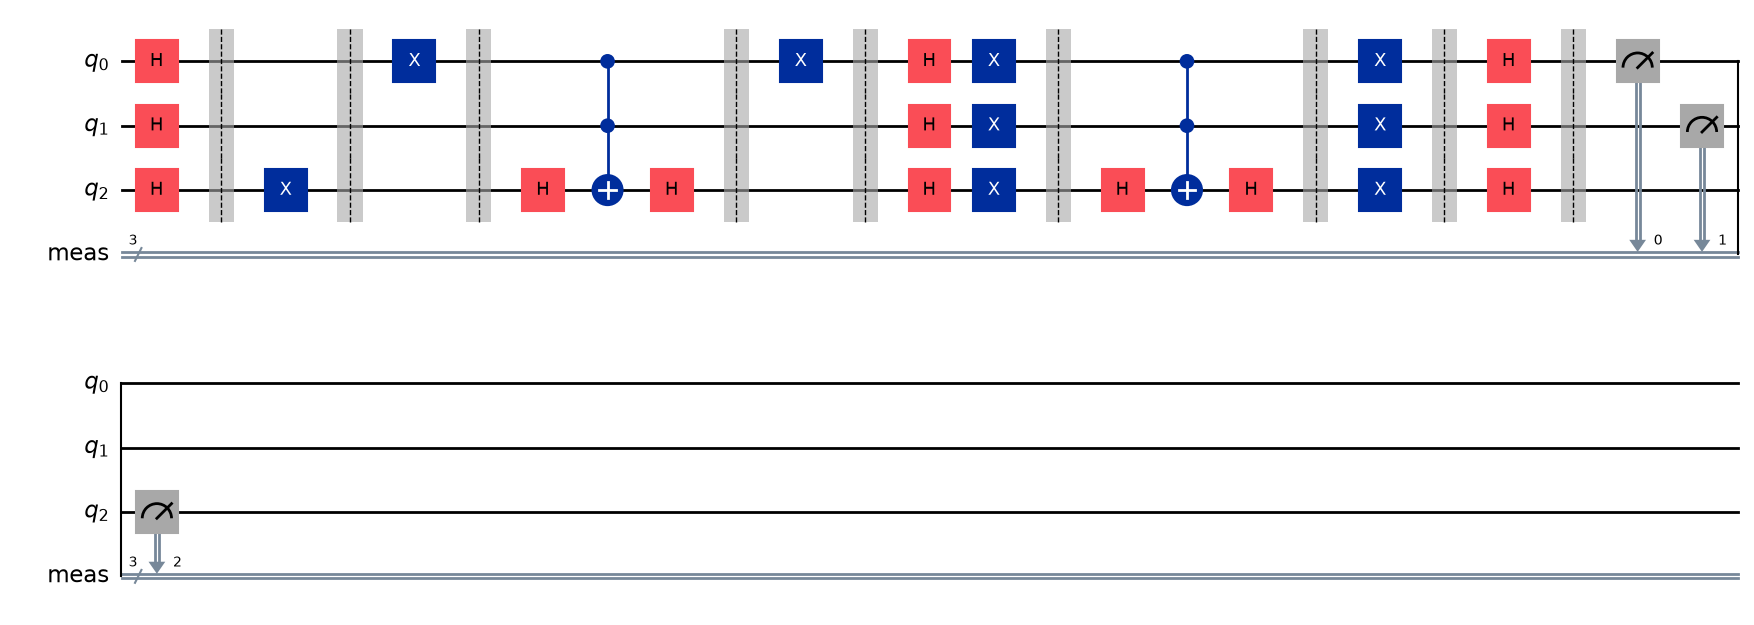

In [14]:
qc.measure_all() # add measurement operators
qc.draw(output='mpl')

In [16]:
from qiskit import QuantumCircuit, transpile
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2

# Login once
QiskitRuntimeService.save_account(
    channel="ibm_quantum_platform",
    token="QmdWblfWNrDdlhjc4qP3CBLxFAedrOJsrGiybF9aF1Rd",
    overwrite=True
)

service = QiskitRuntimeService()

backend = service.least_busy(
    simulator=False,
    operational=True
)

qiskit_runtime_service.__init__:WARNING:2026-09-23 06:08:33,786: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService(). Alternatively, pass instance='auto' or save it to your account for auto-selection without warning.
qiskit_runtime_service.backends:WARNING:2026-09-23 06:08:34,141: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-09-23 06:08:36,487: Using instance: open-instance, plan: open
